In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
togo_data = pd.read_csv('../data/togo-dapaong_qc.csv')

# Display the first few rows of the dataset
togo_data.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-25 00:01,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
1,2021-10-25 00:02,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2,2021-10-25 00:03,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
3,2021-10-25 00:04,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
4,2021-10-25 00:05,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


In [3]:
togo_data.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN


In [4]:
# Check for null values in the dataset
null_values = togo_data.isnull().sum()

# Display null values for each column
print(null_values)

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64


In [6]:
# Convert the 'Timestamp' column to datetime
togo_data['Timestamp'] = pd.to_datetime(togo_data['Timestamp'])

# Check the data types to confirm the change
print(togo_data.dtypes)

Timestamp        datetime64[ns]
GHI                     float64
DNI                     float64
DHI                     float64
ModA                    float64
ModB                    float64
Tamb                    float64
RH                      float64
WS                      float64
WSgust                  float64
WSstdev                 float64
WD                      float64
WDstdev                 float64
BP                        int64
Cleaning                  int64
Precipitation           float64
TModA                   float64
TModB                   float64
Comments                float64
dtype: object


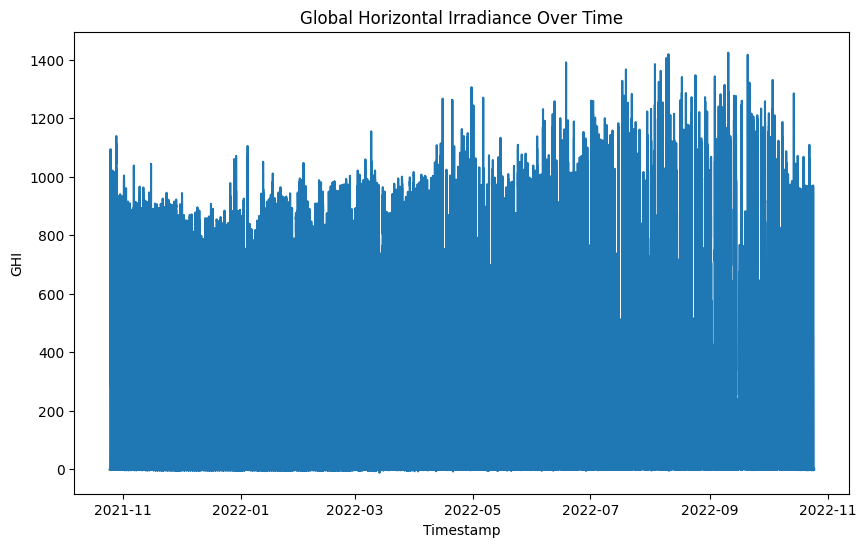

In [9]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=togo_data, x='Timestamp', y='GHI')
plt.title('Global Horizontal Irradiance Over Time')
plt.show()

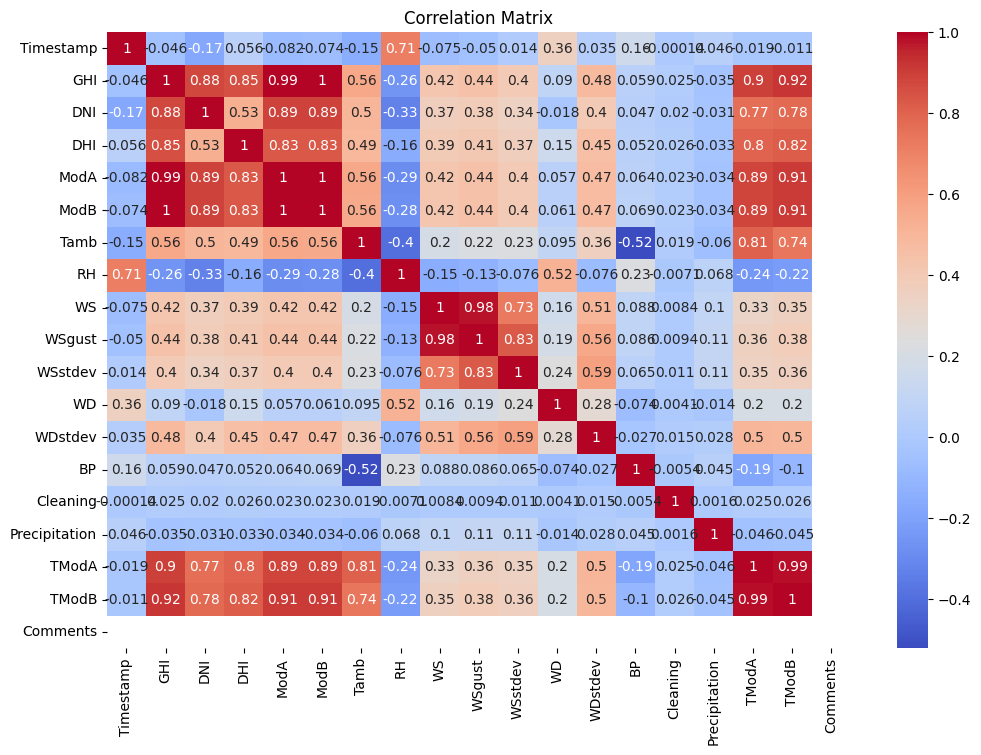

In [10]:
plt.figure(figsize=(12, 8))
correlation_matrix = togo_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

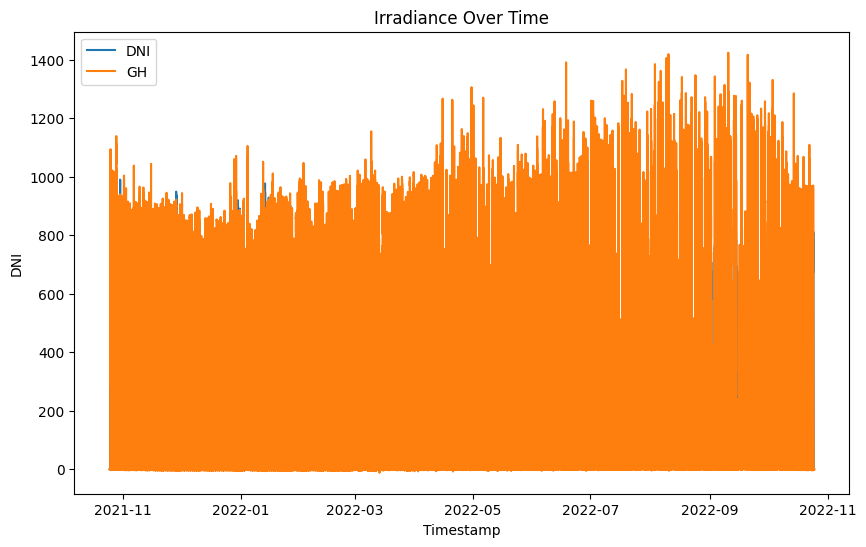

In [12]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=togo_data, x='Timestamp', y='DNI', label='DNI')
sns.lineplot(data=togo_data, x='Timestamp', y='GHI', label='GH')
plt.title('Irradiance Over Time')
plt.legend()
plt.show()

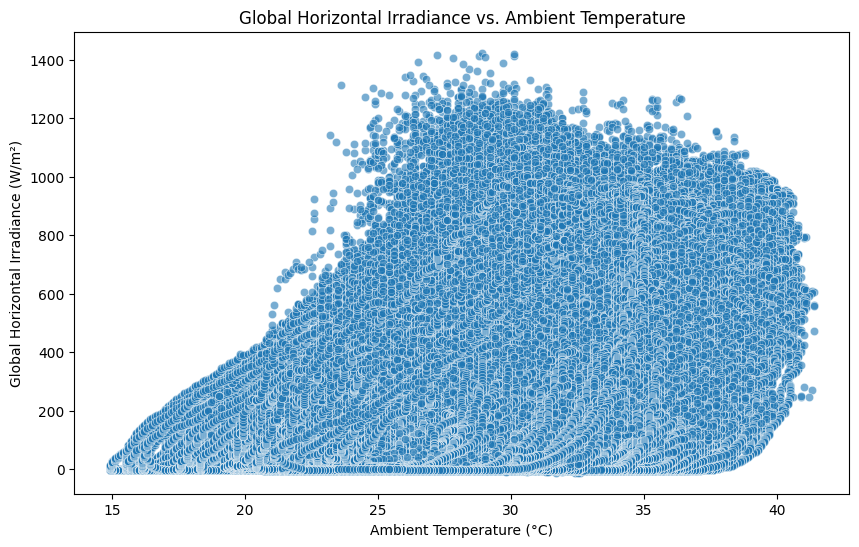

In [15]:
# Compare Variables with Scatter Plots
plt.figure(figsize=(10, 6))
sns.scatterplot(data=togo_data, x='Tamb', y='GHI', alpha=0.6)
plt.title('Global Horizontal Irradiance vs. Ambient Temperature')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Global Horizontal Irradiance (W/m²)')
plt.show()

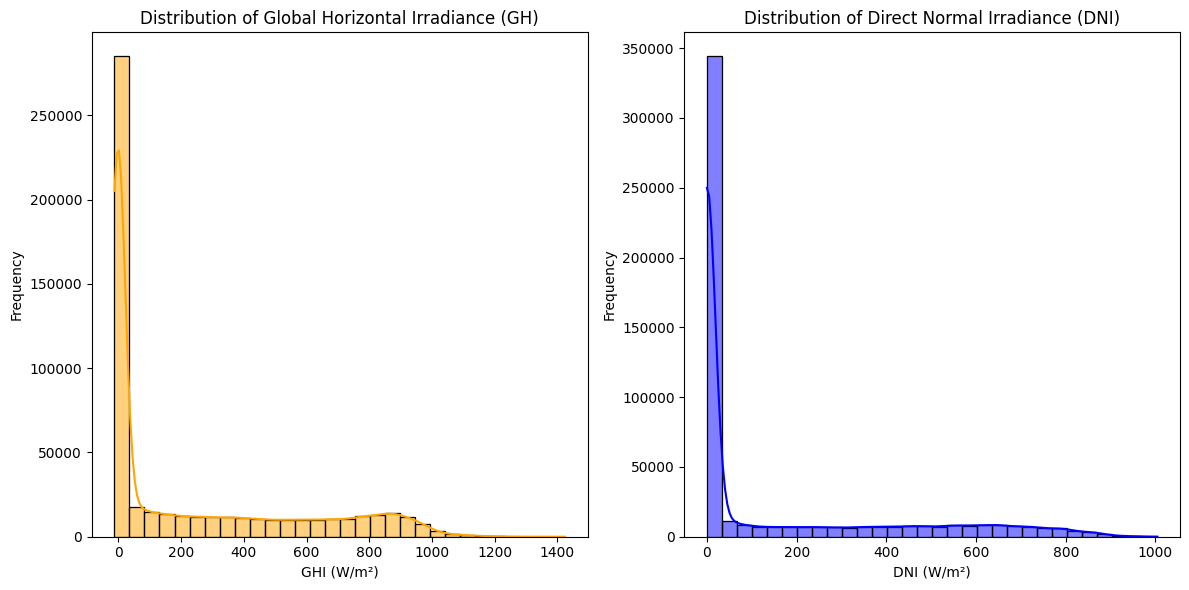

In [16]:
# Set up the figure
plt.figure(figsize=(12, 6))

# Histogram for Global Horizontal Irradiance (GH)
plt.subplot(1, 2, 1)
sns.histplot(togo_data['GHI'], bins=30, kde=True, color='orange')
plt.title('Distribution of Global Horizontal Irradiance (GH)')
plt.xlabel('GHI (W/m²)')
plt.ylabel('Frequency')

# Histogram for Direct Normal Irradiance (DNI)
plt.subplot(1, 2, 2)
sns.histplot(togo_data['DNI'], bins=30, kde=True, color='blue')
plt.title('Distribution of Direct Normal Irradiance (DNI)')
plt.xlabel('DNI (W/m²)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()